In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 0: grade II (246)
# 1: grade III (264)
label_dict = {0: "Grade II", 1: "Grade III"}

# Function to plot the 2D data points
def plot_2d_projection(X, y, ax, title="2D Projection", method="PCA"):
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
    unique_labels = np.unique(y)
    for i, label in enumerate(unique_labels):
        ax.scatter(X[y == label, 0], X[y == label, 1], 
                   color=colors[i % len(colors)], label=label, edgecolor='k', s=30)
    # ax.set_title(f"{title} using {method}")
    ax.set_title(f"{title}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    
# Function to plot the 3D data points
def plot_3d_projection(X, y, ax, title="3D Projection", method="PCA"):
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
    unique_labels = np.unique(y)
    for i, label in enumerate(unique_labels):
        ax.scatter(X[y == label, 0], X[y == label, 1], X[y == label, 2], 
                   color=colors[i % len(colors)], label=label_dict[label], edgecolor='k', s=20)
    ax.set_title(f"{title} using {method}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")
    # legend
    ax.legend(loc='upper right', fontsize=8, markerscale=1.5)

# Load the multi-omics data and concatenate the modality-specific features.
data_dir = "./data/data_MOGONET/LGG/"
data_train_list = []
data_test_list = []
data_list = []
for i in range(1, 4): # num_view = 3
    data_train = np.loadtxt(os.path.join(data_dir, str(i) + "_tr.csv"), delimiter=',')
    data_test = np.loadtxt(os.path.join(data_dir, str(i) + "_te.csv"), delimiter=',')
    data_train_min = np.min(data_train, axis=0, keepdims=True) 
    data_train_max = np.max(data_train, axis=0, keepdims=True)
    data_train = (data_train - data_train_min)/(data_train_max - data_train_min + 1e-10)
    data_test = (data_test - data_train_min)/(data_train_max - data_train_min + 1e-10)
    data_train_list.append(data_train.astype(float))
    data_test_list.append(data_test.astype(float))
    data_list.append(np.concatenate([data_train, data_test], axis=0)) # shape: (num_train+num_test, num_feature)
data = np.concatenate(data_list, axis=1) # shape: (num_train+num_test, num_feature_1 + num_feature_2 + num_feature_3)
label_train = np.loadtxt(os.path.join(data_dir, "labels_tr.csv"), delimiter=',').astype(int)
label_test = np.loadtxt(os.path.join(data_dir, "labels_te.csv"), delimiter=',').astype(int)
label = np.concatenate([label_train, label_test], axis=0) # shape: (num_train+num_test, )
data = np.concatenate([label.reshape(-1, 1), data], axis=1) # shape: (num_train+num_test, num_feature_1 + num_feature_2 + num_feature_3 + 1)

# Apply t-SNE for each modality separately (3D) is correct but here we use the same t-SNE for all modalities may have more similar results
tsne = TSNE(n_components=3, random_state=42)
data_modality_1 = np.concatenate([data_train_list[0], data_test_list[0]], axis=0)
tsne_modality_1 = tsne.fit_transform(data_modality_1)
data_modality_2 = np.concatenate([data_train_list[1], data_test_list[1]], axis=0)
tsne_modality_2 = tsne.fit_transform(data_modality_2)
data_modality_3 = np.concatenate([data_train_list[2], data_test_list[2]], axis=0)
tsne_modality_3 = tsne.fit_transform(data_modality_3)
data_combined = np.concatenate([data_modality_1, data_modality_2, data_modality_3], axis=1)
tsne_result = tsne.fit_transform(data_combined)

# Create a 4x4 grid of subplots
fig = plt.figure(figsize=(21, 20))
ax1 = fig.add_subplot(4, 4, 1, projection='3d')  # Ensure this is 3D
ax1_1 = fig.add_subplot(4, 4, 2)
ax1_2 = fig.add_subplot(4, 4, 3)
ax1_3 = fig.add_subplot(4, 4, 4)
plot_3d_projection(tsne_modality_1, label, ax1, title="Modality 1 embedding", method="t-SNE")
plot_2d_projection(tsne_modality_1[:, [0, 1]], label, ax1_1, title="Modality 1 with dimension (1,2)", method="t-SNE")
plot_2d_projection(tsne_modality_1[:, [0, 2]], label, ax1_2, title="Modality 1 with dimension (1,3)", method="t-SNE")
plot_2d_projection(tsne_modality_1[:, [1, 2]], label, ax1_3, title="Modality 1 with dimension (2,3)", method="t-SNE")
ax2 = fig.add_subplot(4, 4, 5, projection='3d')  # Ensure this is 3D
ax2_1 = fig.add_subplot(4, 4, 6)
ax2_2 = fig.add_subplot(4, 4, 7)
ax2_3 = fig.add_subplot(4, 4, 8)
plot_3d_projection(tsne_modality_2, label, ax2, title="Modality 2 embedding", method="t-SNE")
plot_2d_projection(tsne_modality_2[:, [0, 1]], label, ax2_1, title="Modality 2 with dimension (1,2)", method="t-SNE")
plot_2d_projection(tsne_modality_2[:, [0, 2]], label, ax2_2, title="Modality 2 with dimension (1,3)", method="t-SNE")
plot_2d_projection(tsne_modality_2[:, [1, 2]], label, ax2_3, title="Modality 2 with dimension (2,3)", method="t-SNE")
ax3 = fig.add_subplot(4, 4, 9, projection='3d')  # Ensure this is 3D
ax3_1 = fig.add_subplot(4, 4, 10)
ax3_2 = fig.add_subplot(4, 4, 11)
ax3_3 = fig.add_subplot(4, 4, 12)
plot_3d_projection(tsne_modality_3, label, ax3, title="Modality 3 embedding", method="t-SNE")
plot_2d_projection(tsne_modality_3[:, [0, 1]], label, ax3_1, title="Modality 3 with dimension (1,2)", method="t-SNE")
plot_2d_projection(tsne_modality_3[:, [0, 2]], label, ax3_2, title="Modality 3 with dimension (1,3)", method="t-SNE")
plot_2d_projection(tsne_modality_3[:, [1, 2]], label, ax3_3, title="Modality 3 with dimension (2,3)", method="t-SNE")
ax4 = fig.add_subplot(4, 4, 13, projection='3d')  # Ensure this is 3D
ax4_1 = fig.add_subplot(4, 4, 14)
ax4_2 = fig.add_subplot(4, 4, 15)
ax4_3 = fig.add_subplot(4, 4, 16)
plot_3d_projection(tsne_result, label, ax4, title="All Modalities embedding", method="t-SNE")
plot_2d_projection(tsne_result[:, [0, 1]], label, ax4_1, title="All Modalities with dimension (1,2)", method="t-SNE")
plot_2d_projection(tsne_result[:, [0, 2]], label, ax4_2, title="All Modalities with dimension (1,3)", method="t-SNE")
plot_2d_projection(tsne_result[:, [1, 2]], label, ax4_3, title="All Modalities with dimension (2,3)", method="t-SNE")
fig.suptitle("Embedding Visualization of LGG Multi-Omics Data using t-SNE", fontsize=20, fontweight='bold', y=1.02)
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.3, hspace=0.3) # Adjust layout and show the plot
plt.tight_layout()
plt.savefig("./data/data_MOGONET/LGG/LGG_multi_omics_tsne.png", dpi=300, bbox_inches='tight')
# plt.show()
plt.close()

In [2]:
print(tsne_modality_1.shape)
print(tsne_modality_2.shape)
print(tsne_modality_3.shape)
print(tsne_result.shape)

(510, 3)
(510, 3)
(510, 3)
(510, 3)


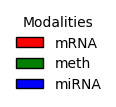

In [3]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch

modality_color_list = ['r', 'g', 'b', 'y', 'c', 'm', 'k']
fig, ax = plt.subplots(figsize=(1, 1))
legend_elements = [Patch(facecolor=modality_color_list[0], edgecolor='black', label='mRNA'),
                    Patch(facecolor=modality_color_list[1], edgecolor='black', label='meth'),
                    Patch(facecolor=modality_color_list[2], edgecolor='black', label='miRNA')]
legend = ax.legend(handles=legend_elements, title="Modalities", loc='center', frameon=False, edgecolor='black', markerscale=10.5, fontsize=10, ncol=1, columnspacing=3.5)
ax.set_axis_off()
plt.tight_layout()
plt.show()

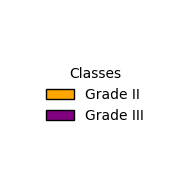

In [4]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch

label_dict = {0: "Grade II", 1: "Grade III"}
label_color_list = ['orange', 'purple', 'pink', 'yellow', 'cyan', 'magenta', 'black']
fig, ax = plt.subplots(figsize=(2, 2))
legend_elements = [Patch(facecolor=label_color_list[0], edgecolor='black', label='Grade II'),
                   Patch(facecolor=label_color_list[1], edgecolor='black', label='Grade III')]
legend = ax.legend(handles=legend_elements, title="Classes", loc='center', frameon=False, edgecolor='black', markerscale=10.5, fontsize=10, ncol=1, columnspacing=3.5)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.spatial.distance import cdist, pdist
from sklearn.metrics.pairwise import cosine_similarity

def load_feature_and_hyperedge(data_dir, use_mRNA=True, use_meth=True, use_miRNA=True, k_list=[100], is_prob=True, m_prob=1, edge_type='euclid'):
    def construct_hyperedge_with_KNN(X, label, modality, k_list=[10], is_prob=True, m_prob=1, edge_type='euclid'):
        # Additional Information
        label_distance_mat = np.zeros((data_list[0].shape[0], data_list[0].shape[0])) # shape: (num_train+num_test, num_train+num_test)
        for i in range(label.shape[0]):
            for j in range(label.shape[0]):
                if label[i] == label[j]:
                    label_distance_mat[i, j] = 1
                else:
                    label_distance_mat[i, j] = 1.15
        label_similarity_mat = np.zeros((data_list[0].shape[0], data_list[0].shape[0])) # shape: (num_train+num_test, num_train+num_test)
        for i in range(label.shape[0]):
            for j in range(label.shape[0]):
                if label[i] == label[j]:
                    label_similarity_mat[i, j] = 1
                else:
                    label_similarity_mat[i, j] = 0.5
                    
        # Construct the hyperedge incidence matrix
        hyperedge_mat_list = []
        for k in k_list:
            if edge_type == 'euclid':
                distance_mat = cdist(X, X, 'euclid')
                distance_mat = distance_mat * label_distance_mat
                # save the distance matrix
                np.savetxt(os.path.join(data_dir, "distance_mat_modality_{}.csv".format(modality)), distance_mat, delimiter=',')
                # load the distance matrix
                # distance_mat = np.loadtxt(os.path.join(data_dir, "distance_mat_modality_{}.csv".format(modality)), delimiter=',')
                distance_mat = distance_mat
                hyperedge_mat = np.zeros(distance_mat.shape)
                for center_idx in range(distance_mat.shape[0]):
                    distance_mat[center_idx, center_idx] = 0
                    distance_vec = distance_mat[center_idx]
                    distance_vec_avg = np.average(distance_vec) # equivalent to np.mean(distance_vec)
                    nearest_idx = np.array(np.argsort(distance_vec)).squeeze() # from small to large
                    nearest_idx[k - 1] = center_idx if not np.any(nearest_idx[:k] == center_idx) else nearest_idx[k - 1] # add the center node to the nearest neighbors if it is not in the top k
                    for node_idx in nearest_idx[:k]:
                        hyperedge_mat[node_idx, center_idx] = np.exp(-distance_vec[node_idx] ** 2 / (m_prob * distance_vec_avg) ** 2) if is_prob else 1.0 # Gaussian kernel for computing the hyperedge weight
            elif edge_type == 'pearson':
                similarity_mat = pd.DataFrame(X.T).corr(method='pearson').to_numpy()
                similarity_mat = similarity_mat * label_similarity_mat
                # save the similarity matrix
                np.savetxt(os.path.join(data_dir, "similarity_mat_modality_{}.csv".format(modality)), similarity_mat, delimiter=',')
                # load the similarity matrix
                # similarity_mat = np.loadtxt(os.path.join(data_dir, "similarity_mat_modality_{}.csv".format(modality)), delimiter=',')
                hyperedge_mat = np.zeros(similarity_mat.shape)
                for center_idx in range(similarity_mat.shape[0]):
                    similarity_mat[center_idx, center_idx] = -999
                    similarity_vec = similarity_mat[center_idx]
                    nearest_idx = np.array(np.argsort(similarity_vec)).squeeze()
                    nearest_idx = nearest_idx[::-1] # from large to small
                    nearest_idx[k - 1] = center_idx if not np.any(nearest_idx[:k] == center_idx) else nearest_idx[k - 1] # add the center node to the nearest neighbors if it is not in the top k
                    for node_idx in nearest_idx[:k]:
                        hyperedge_mat[node_idx, center_idx] = 1-np.exp(-(similarity_vec[node_idx] + 1.0) ** 2 ) if is_prob else 1.0 # formulation: 1 - exp(-d^2) for computing the hyperedge weight
            hyperedge_mat_list.append(hyperedge_mat)
            
        hyperedge_mat = np.hstack(hyperedge_mat_list)
        return hyperedge_mat
    
    def generate_G_from_H(H, variable_weight=False):
        # Calculate G from hypgerraph incidence matrix H, where G = DV2 * H * W * invDE * HT * DV2
        H = np.array(H) # shape: N X M, N is the number of nodes, M is the number of hyperedges, W means the weight of the hyperedge
        W = np.ones(H.shape[1]) # the weight of the hyperedge
        DV = np.sum(H * W, axis=1) # the degree of the node
        DE = np.sum(H, axis=0) # the degree of the hyperedge
        invDE = np.mat(np.diag(np.power(DE, -1))) # shape: M X M
        invDV2 = np.mat(np.diag(np.power(DV, -0.5))) # shape: N X N
        W = np.mat(np.diag(W)) # shape: M X M
        H = np.mat(H) # shape: N X M
        if variable_weight:
            return invDV2 * H, W, invDE * H.T * invDV2
        else:
            return invDV2 * H * W * invDE * H.T * invDV2 # shape: N X N

    # Load the multi-omics data and concatenate the modality-specific features.
    data_train_list = []
    data_test_list = []
    data_list = []
    for i in range(1, 4): # num_view = 3
        data_train = np.loadtxt(os.path.join(data_dir, str(i) + "_tr.csv"), delimiter=',')
        data_test = np.loadtxt(os.path.join(data_dir, str(i) + "_te.csv"), delimiter=',')
        data_train_min = np.min(data_train, axis=0, keepdims=True) 
        data_train_max = np.max(data_train, axis=0, keepdims=True)
        data_train = (data_train - data_train_min)/(data_train_max - data_train_min + 1e-10)
        data_test = (data_test - data_train_min)/(data_train_max - data_train_min + 1e-10)
        data_train_list.append(data_train.astype(float))
        data_test_list.append(data_test.astype(float))
        data_list.append(np.concatenate([data_train, data_test], axis=0)) # shape: (num_train+num_test, num_feature)
    label_train = np.loadtxt(os.path.join(data_dir, "labels_tr.csv"), delimiter=',').astype(int)
    label_test = np.loadtxt(os.path.join(data_dir, "labels_te.csv"), delimiter=',').astype(int)
    label = np.concatenate([label_train, label_test], axis=0) # shape: (num_train+num_test, )
    data_train_indices = np.arange(label_train.shape[0])
    data_test_indices = np.arange(label_train.shape[0], label_train.shape[0] + label_test.shape[0])
    # data_list: list of numpy arrays, each array is a matrix with shape (num_train+num_test, num_feature)
    # label: numpy array with shape (num_train+num_test, )
    # data_train_indices: numpy array with shape (num_train, )
    # data_test_indices: numpy array with shape (num_test, )
    print('data_list mRNA shape:', data_list[0].shape)
    print('data_list meth shape:', data_list[1].shape)
    print('data_list miRNA shape:', data_list[2].shape)
    print('label shape:', label.shape)
    print('data_train_indices shape:', data_train_indices.shape)
    print('data_test_indices shape:', data_test_indices.shape)

    # Construct the multi-omics hypergraph incidence matrix and concatenate the modality-specific hyperedges.
    hyperedge_mRNA = construct_hyperedge_with_KNN(tsne_modality_1, label, modality=0, k_list=k_list, is_prob=is_prob, m_prob=m_prob, edge_type=edge_type) if use_mRNA else None
    hyperedge_meth = construct_hyperedge_with_KNN(tsne_modality_2, label, modality=1, k_list=k_list, is_prob=is_prob, m_prob=m_prob, edge_type=edge_type) if use_meth else None
    hyperedge_miRNA = construct_hyperedge_with_KNN(tsne_modality_3, label, modality=2, k_list=k_list, is_prob=is_prob, m_prob=m_prob, edge_type=edge_type) if use_miRNA else None
    hyperedge_multi_omics = None
    for hyperedge in [hyperedge_mRNA, hyperedge_meth, hyperedge_miRNA]:
        if hyperedge is not None:
            hyperedge_multi_omics = hyperedge if hyperedge_multi_omics is None else np.hstack((hyperedge_multi_omics, hyperedge))
    # hyperedge_multi_omics: numpy array with shape (num_train+num_test, num_hyperedge * num_view)
    print('hyperedge_multi_omics shape:', hyperedge_multi_omics.shape)
    
    # Convert the multi-omics hyperedge to pre calculated G (G = DV2 * H * W * invDE * HT * DV2)
    pre_calc_G = generate_G_from_H(hyperedge_multi_omics, variable_weight=False)
    print('pre_calculate hypegraph G shape:', pre_calc_G.shape)
    print('label shape:', label.shape)
    return data_list, label, data_train_indices, data_test_indices, hyperedge_multi_omics, pre_calc_G

In [ ]:
data_list, label, data_train_indices, data_test_indices, hyperedge_multi_omics, pre_calc_G = load_feature_and_hyperedge('./data/data_MOGONET/LGG', use_mRNA=True, use_meth=True, use_miRNA=True, k_list=[300], is_prob=True, m_prob=1, edge_type='euclid')
label_sort = np.argsort(label) # according to the label to sort the hyperedge incidence matrix
hyperedge_multi_omics = hyperedge_multi_omics[label_sort, :]
data_list[0] = data_list[0][label_sort, :]
data_list[1] = data_list[1][label_sort, :]
data_list[2] = data_list[2][label_sort, :]
data = np.concatenate([data_list[0], data_list[1], data_list[2]], axis=1)
print('data shape:', data.shape)
label = label[label_sort]
print('label shape:', label.shape)

data_list mRNA shape: (510, 2000)
data_list meth shape: (510, 2000)
data_list miRNA shape: (510, 548)
label shape: (510,)
data_train_indices shape: (357,)
data_test_indices shape: (153,)
hyperedge_multi_omics shape: (510, 1530)
pre_calculate hypegraph G shape: (510, 510)
label shape: (510,)
data shape: (510, 4548)
label shape: (510,)


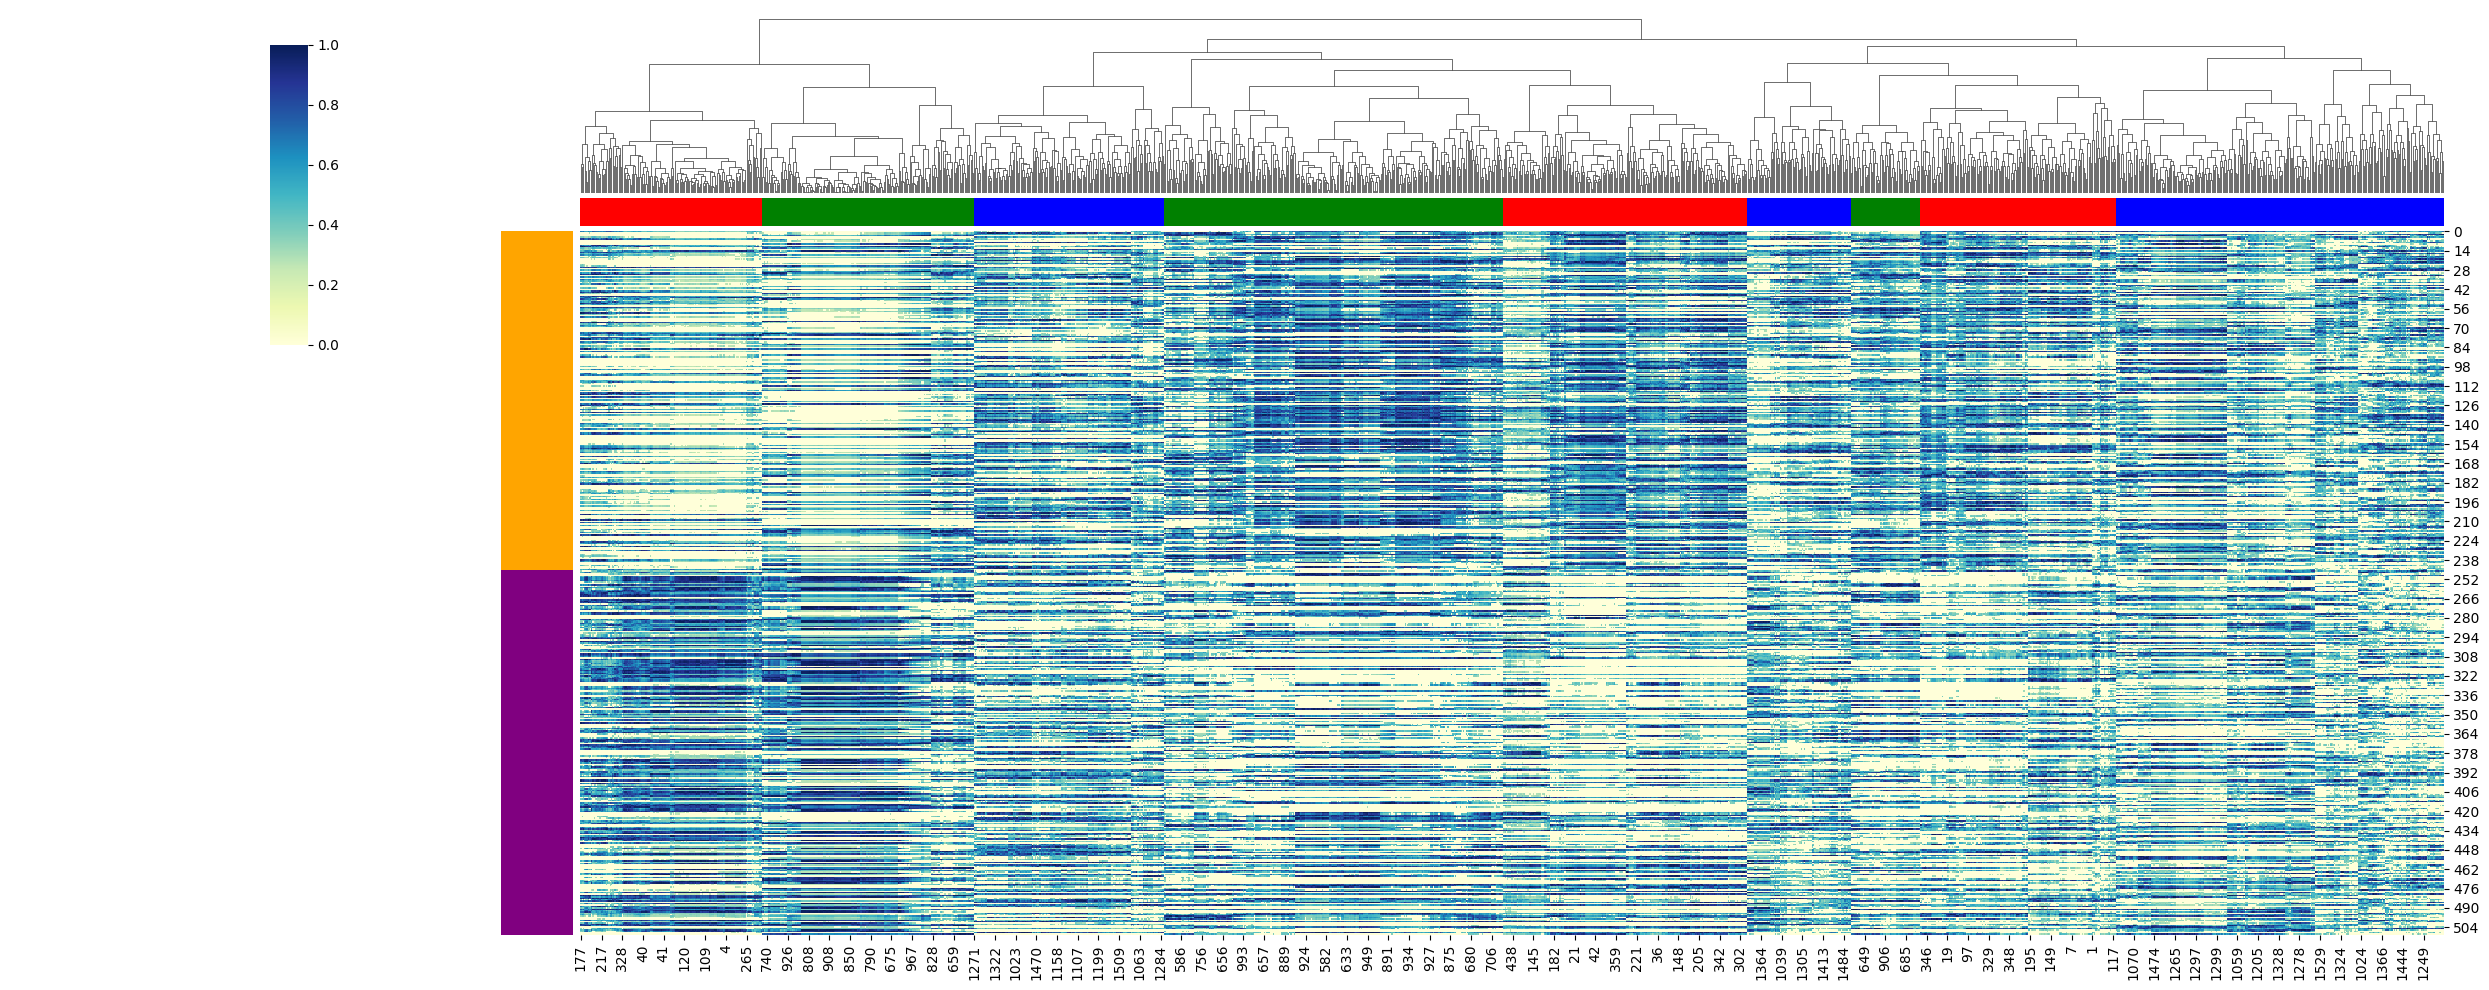

In [ ]:
# visualize the hyperedge incidence matrix
label_color_list = ['orange', 'purple', 'pink', 'yellow', 'cyan', 'magenta', 'black']
modality_color_list = ['r', 'g', 'b', 'y', 'c', 'm', 'k']
sns.clustermap(hyperedge_multi_omics,
            cmap='YlGnBu',
            row_cluster=False,
            col_cluster=True,
            figsize=(25, 10),
            row_colors=[label_color_list[i] for i in label],
            col_colors=[modality_color_list[int(i)] for i in [0]*len(data_list[0]) + [1]*len(data_list[1]) + [2]*len(data_list[2])],
            cbar_pos=(0.11, .65, .015, .3))
plt.savefig('./data/data_MOGONET/LGG/LGG_multiomics_hyperedge_k_300.png', dpi=300, bbox_inches='tight')
plt.show()

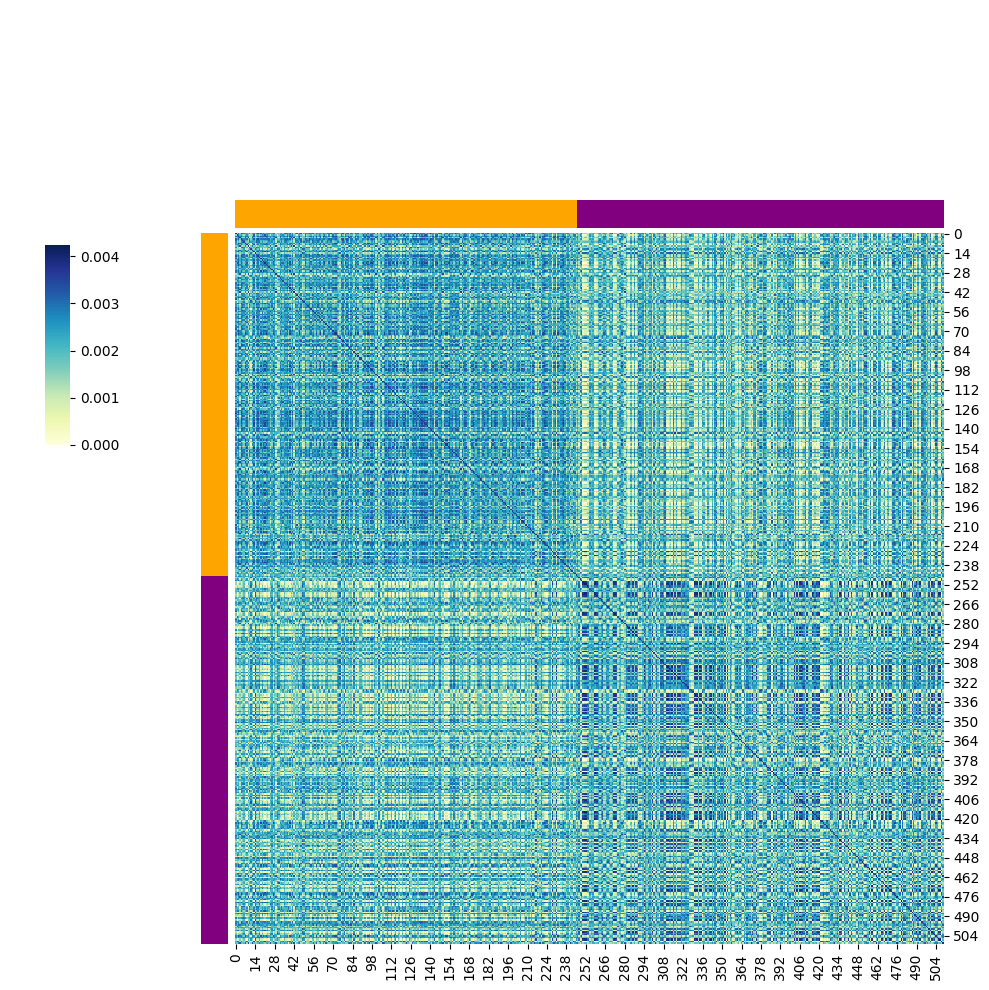

In [ ]:
# visualize the hyperedge incidence matrix
label_color_list = ['orange', 'purple', 'pink', 'yellow', 'cyan', 'magenta', 'black']
modality_color_list = ['r', 'g', 'b', 'y', 'c', 'm', 'k']

pre_calc_G = pre_calc_G[label_sort, :]
pre_calc_G = pre_calc_G[:, label_sort]
sns.clustermap(pre_calc_G,
            cmap='YlGnBu',
            row_cluster=False,
            col_cluster=False,
            figsize=(10, 10),
            row_colors=[label_color_list[i] for i in label],
            col_colors=[label_color_list[i] for i in label],
            cbar_pos=(0.05, .55, .025, .2))
plt.savefig('./data/data_MOGONET/LGG/LGG_multiomics_hyperedge_G_k_300.png', dpi=300, bbox_inches='tight')
plt.show()